In [17]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [18]:
train = pd.read_csv("train_hw.csv")
test = pd.read_csv("test_hw.csv")

In [19]:
test_ids = test["Id"]
train.drop("Id", axis=1, inplace=True)
test.drop("Id", axis=1, inplace=True)

In [20]:
from sklearn.model_selection import train_test_split
X = train.drop("SalePrice", axis=1)
y = np.log1p(train["SalePrice"])

In [34]:
#Создаём новые поля
def add_features(df):
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBath'] = df['FullBath'] + 0.5*df['HalfBath'] + df['BsmtFullBath'] + 0.5*df['BsmtHalfBath']
    df['TotalPorch'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']
    df['Age'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    return df

In [22]:
X = add_features(X)
test = add_features(test)

In [24]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [25]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [26]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

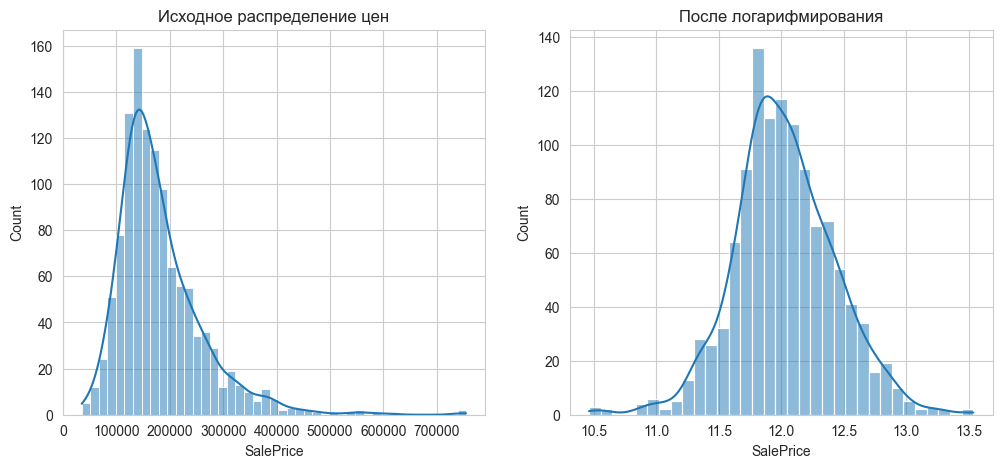

In [28]:
import seaborn as sns
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train['SalePrice'], kde=True)
plt.title('Исходное распределение цен')

plt.subplot(1, 2, 2)
sns.histplot(y, kde=True)
plt.title('После логарифмирования')
plt.show()

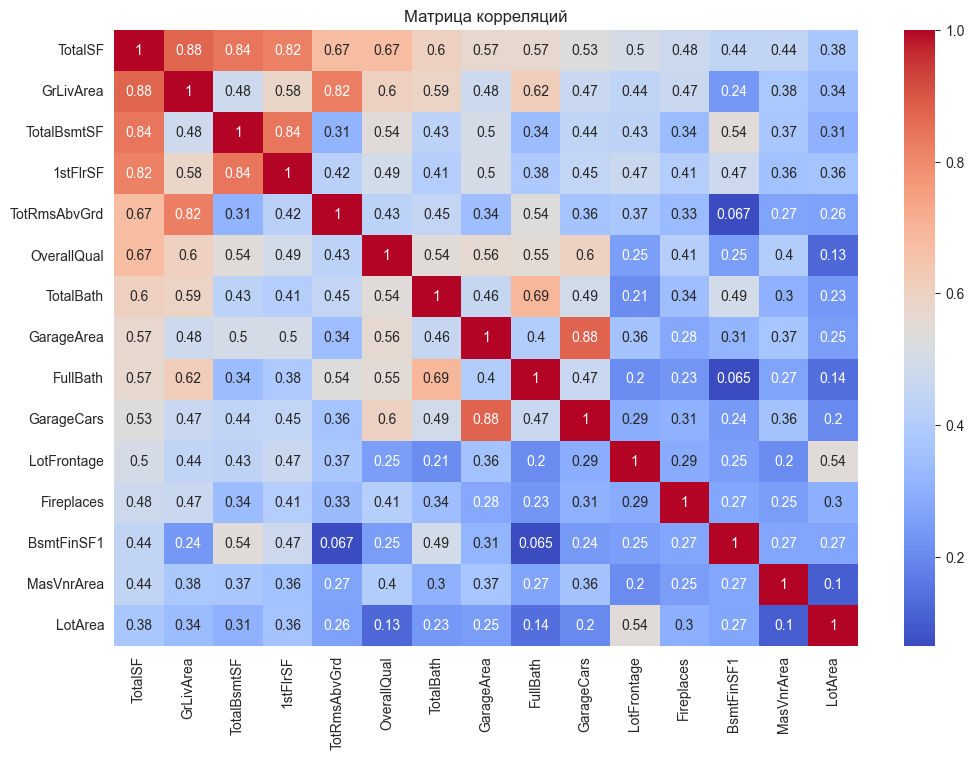

In [29]:
# Выбираем 15 наиболее коррелирующих признаков, можно увидеть, что новые введённые поля хорошо коррелируют с таргетом
corr_matrix = X[num_cols].corr().abs()
top_features = corr_matrix.nlargest(15, 'TotalSF')['TotalSF'].index

plt.figure(figsize=(12, 8))
sns.heatmap(X[top_features].corr(), annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

In [10]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())  # Простая линейная регрессия
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'L...
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

In [32]:
val_pred = model.predict(X_val)
print(f"Validation RMSE: {np.sqrt(mean_squared_error(y_val, val_pred))}")

test_pred = model.predict(test)

final_predictions = np.expm1(test_pred)

submission = pd.DataFrame({'Id': test_ids, 'SalePrice': final_predictions})
submission.to_csv('submission.csv', index=False)

print("Файл submission.csv готов!")

Validation RMSE: 0.134355832281944
Файл submission.csv готов!


In [31]:
#Модель без регуляризации
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)
pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, pred))
print(f"RMSE: {rmse:.4f}")

RMSE: 0.1344


In [35]:
from sklearn.linear_model import Ridge

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

model.fit(X_train, y_train)
pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, pred))
print(f"RMSE: {rmse:.4f}")

RMSE: 0.1374
